# Exploratory Data Analysis

Kham pha phan phoi luong mua, target 6 gio toi va cac feature thoi tiet.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'Notebooks' else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.aq_course_ml.config import FEATURE_COLUMNS, PROCESSED_DATA_PATH, REGRESSION_TARGET

In [2]:
df = pd.read_csv(PROCESSED_DATA_PATH, parse_dates=['timestamp'])
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56094 entries, 0 to 56093
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   timestamp                   56094 non-null  datetime64[ns]
 1   rain                        56094 non-null  float64       
 2   temperature_2m              56094 non-null  float64       
 3   relative_humidity_2m        56094 non-null  int64         
 4   dew_point_2m                56094 non-null  float64       
 5   pressure_msl                56094 non-null  float64       
 6   surface_pressure            56094 non-null  float64       
 7   wind_speed_10m              56094 non-null  float64       
 8   wind_direction_10m          56094 non-null  int64         
 9   wind_gusts_10m              56094 non-null  float64       
 10  cloud_cover                 56094 non-null  int64         
 11  cloud_cover_low             56094 non-null  int64     

,timestamp,rain,temperature_2m,relative_humidity_2m,dew_point_2m,pressure_msl,surface_pressure,wind_speed_10m,wind_direction_10m,wind_gusts_10m,...,rain_lag_1h,rain_lag_3h,rain_roll_sum_6h,rain_roll_sum_12h,temp_lag_1h,humidity_lag_1h,dew_point_lag_1h,cloud_cover_lag_1h,target_rain_next_6h,target_rain_alert_6h
0,2020-01-01 12:00:00,0.0,22.4,69,16.5,1024.1,1022.0,8.5,144,18.4,...,0.0,0.0,0.0,1.0,23.0,65.0,16.1,98.0,3.3,1
1,2020-01-01 13:00:00,0.1,21.9,73,16.9,1023.1,1021.0,9.3,152,19.1,...,0.0,0.0,0.0,0.6,22.4,69.0,16.5,98.0,3.2,1
2,2020-01-01 14:00:00,0.6,21.2,79,17.5,1022.4,1020.3,9.0,157,18.7,...,0.1,0.0,0.1,0.4,21.9,73.0,16.9,95.0,2.6,1
3,2020-01-01 15:00:00,1.0,20.6,86,18.2,1022.1,1020.0,9.6,160,18.4,...,0.6,0.0,0.7,0.9,21.2,79.0,17.5,93.0,1.6,1
4,2020-01-01 16:00:00,0.7,20.3,88,18.3,1022.1,1020.0,9.0,164,17.3,...,1.0,0.1,1.7,1.8,20.6,86.0,18.2,99.0,0.9,0


In [3]:
df[['rain', 'target_rain_next_6h']].describe()

,rain,target_rain_next_6h
count,56094.000000,56094.000000
mean,0.246952,1.481568
std,1.047987,4.387461
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.100000,0.700000
max,26.400000,98.100000


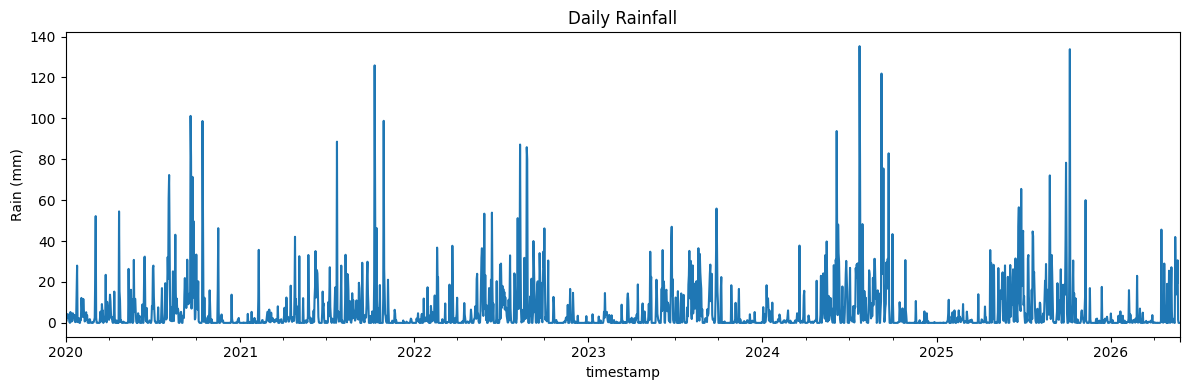

In [4]:
daily = df.set_index('timestamp')['rain'].resample('D').sum()
daily.plot(figsize=(12, 4), title='Daily Rainfall')
plt.ylabel('Rain (mm)')
plt.tight_layout()

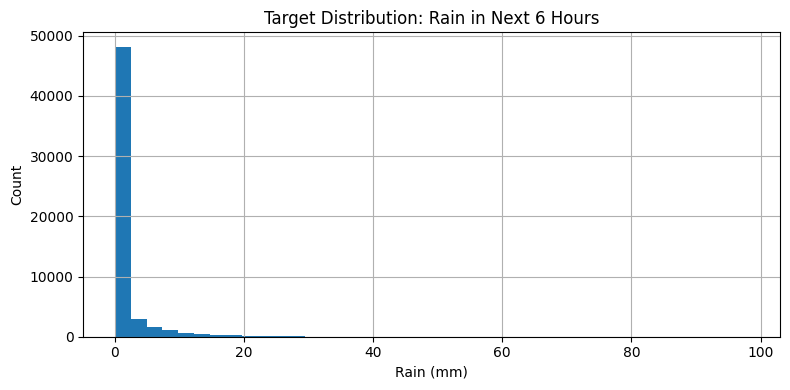

In [5]:
df['target_rain_next_6h'].hist(bins=40, figsize=(8, 4))
plt.title('Target Distribution: Rain in Next 6 Hours')
plt.xlabel('Rain (mm)')
plt.ylabel('Count')
plt.tight_layout()

## Correlation Heatmaps

Chia correlation thanh nhieu nhom feature de heatmap de doc hon: bien thoi tiet goc, feature thoi gian, lag/rolling va correlation voi target.

In [6]:
def plot_corr_heatmap(columns, title, figsize=(10, 8)):
    available_columns = [
        column
        for column in columns
        if column in df.columns and pd.api.types.is_numeric_dtype(df[column])
    ]
    corr_matrix = df[available_columns].corr(numeric_only=True)

    plt.figure(figsize=figsize)
    sns.heatmap(
        corr_matrix,
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        center=0,
        annot=True,
        fmt='.2f',
        annot_kws={'size': 8},
        linewidths=0.4,
        cbar_kws={'label': 'Correlation'},
    )
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()


weather_columns = [
    'rain',
    'temperature_2m',
    'relative_humidity_2m',
    'dew_point_2m',
    'pressure_msl',
    'surface_pressure',
    'wind_speed_10m',
    'wind_direction_10m',
    'wind_gusts_10m',
    'cloud_cover',
    'cloud_cover_low',
    'cloud_cover_mid',
    'cloud_cover_high',
    'et0_fao_evapotranspiration',
    'vapour_pressure_deficit',
    REGRESSION_TARGET,
]

time_columns = [
    'hour',
    'day_of_week',
    'month',
    'is_weekend',
    'hour_sin',
    'hour_cos',
    'month_sin',
    'month_cos',
    REGRESSION_TARGET,
]

lag_rolling_columns = [
    'rain_lag_1h',
    'rain_lag_3h',
    'rain_roll_sum_6h',
    'rain_roll_sum_12h',
    'temp_lag_1h',
    'humidity_lag_1h',
    'dew_point_lag_1h',
    'cloud_cover_lag_1h',
    REGRESSION_TARGET,
]

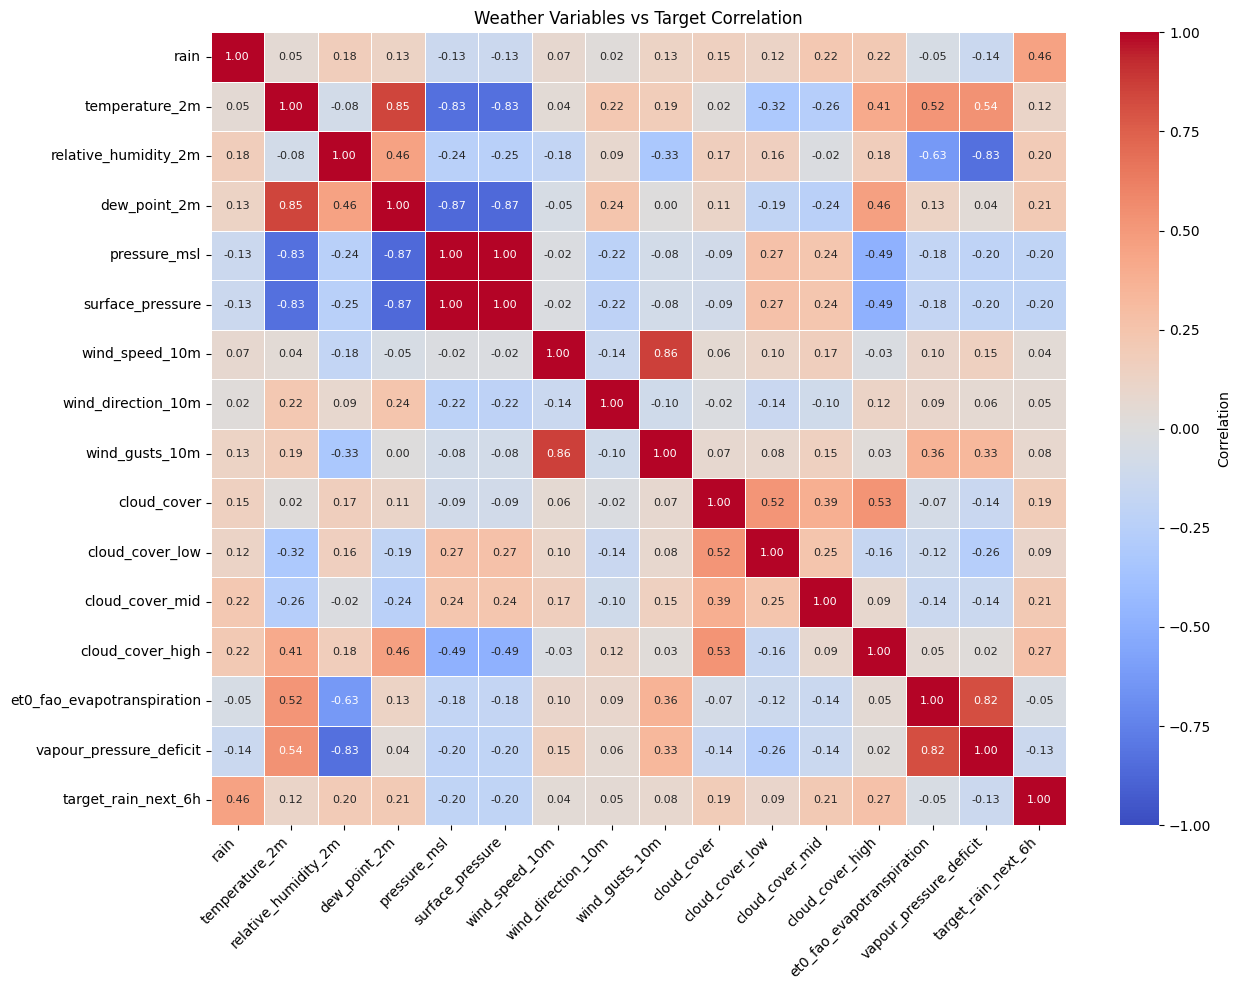

In [7]:
plot_corr_heatmap(weather_columns, 'Weather Variables vs Target Correlation', figsize=(13, 10))

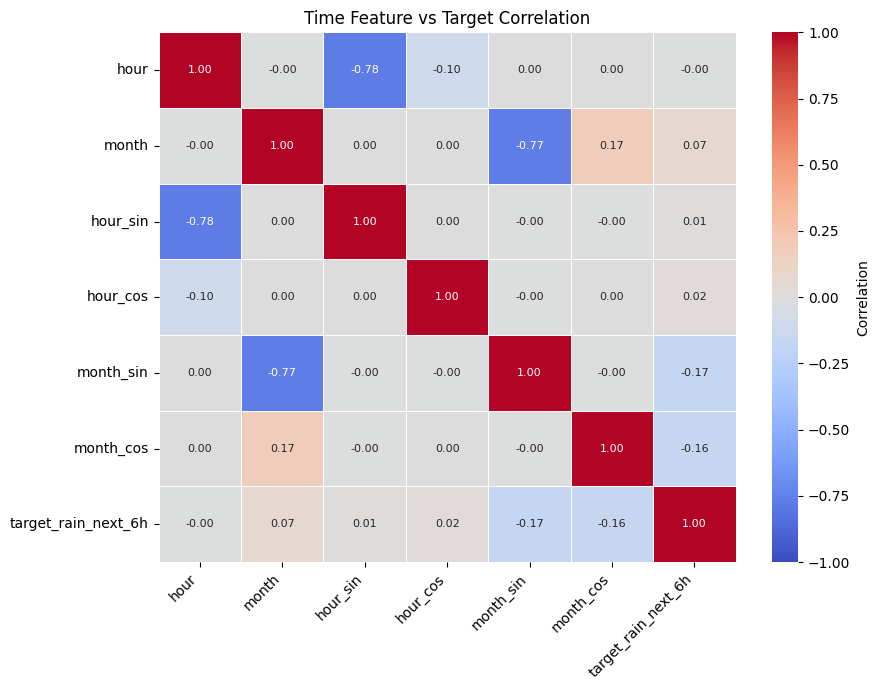

In [8]:
plot_corr_heatmap(time_columns, 'Time Feature vs Target Correlation', figsize=(9, 7))

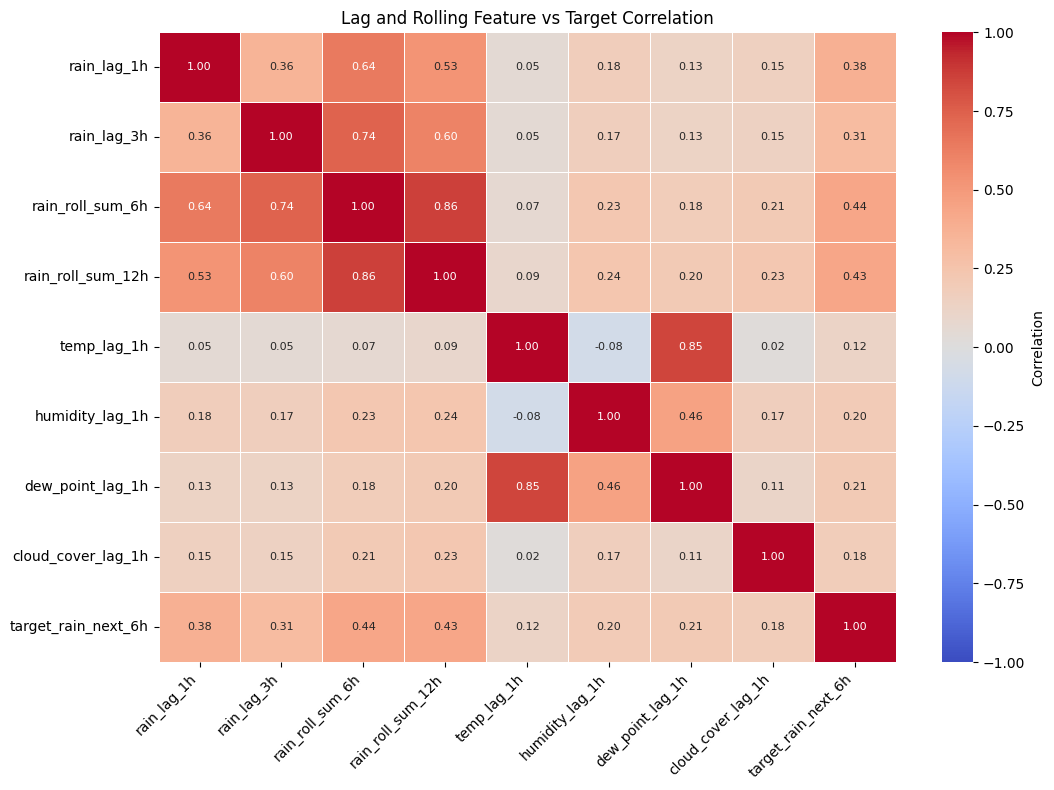

In [9]:
plot_corr_heatmap(lag_rolling_columns, 'Lag and Rolling Feature vs Target Correlation', figsize=(11, 8))

In [10]:
target_corr_columns = [
    column
    for column in FEATURE_COLUMNS
    if column in df.columns and pd.api.types.is_numeric_dtype(df[column])
] + [REGRESSION_TARGET]

target_corr = df[target_corr_columns].corr(numeric_only=True)[REGRESSION_TARGET]
target_corr.drop(REGRESSION_TARGET).sort_values(key=lambda series: series.abs(), ascending=False).to_frame('correlation_with_target')

,correlation_with_target
rain,0.455212
rain_roll_sum_6h,0.436825
rain_roll_sum_12h,0.432061
rain_lag_1h,0.375393
rain_lag_3h,0.305298
cloud_cover_high,0.273412
cloud_cover_mid,0.214202
dew_point_lag_1h,0.208287
dew_point_2m,0.206317
relative_humidity_2m,0.201687
